# Chapter 22: Analysis of variance — the multilevel model

Reproducing examples from Gelman & Hill (2007),
*Data Analysis Using Regression and Multilevel/Hierarchical Models*,
Chapter 22, using **interlace**.

The central insight of this chapter: **classical ANOVA and multilevel
models answer the same question** — how much variation lies between
groups vs within groups — but the multilevel approach has two advantages:

1. **Partial pooling**: group means are shrunk toward the grand mean,
   with more shrinkage for groups with fewer observations.
2. **Uncertainty propagation**: the multilevel model estimates how much
   between-group variation exists, rather than treating it as known.

**Datasets:**
- **Pilots** (Section 22.1): 5 pilot groups × 8 flight scenarios — crossed design
- **Radon** (Section 22.4): 919 measurements across 85 Minnesota counties — nested design

| Section | Analysis | Model |
|---------|----------|-------|
| 22.1 | Classical two-way ANOVA on pilots | `aov(y ~ group + scenario)` |
| 22.1 | Multilevel crossed RE on pilots | `y ~ 1 + (1\|group) + (1\|scenario)` |
| 22.4 | Classical one-way ANOVA on radon | `aov(y ~ county)` |
| 22.4 | Multilevel varying intercept on radon | `y ~ 1 + (1\|county)` |

In [1]:
import json
import numpy as np
import pandas as pd
import interlace
from pathlib import Path
from plotnine import (
    ggplot, aes,
    geom_point, geom_segment, geom_hline, geom_vline,
    geom_abline, geom_bar, geom_errorbar, geom_text,
    facet_wrap, labs, theme_bw, theme, element_text,
    scale_color_manual, scale_shape_manual,
    coord_flip,
)

FIXTURE_DIR = Path("../../../tests/fixtures")

## 1. Pilots data: classical two-way ANOVA (Section 22.1)

The pilots dataset has 40 observations: 5 pilot groups tested on 8 flight
scenarios. The outcome $y$ is the success rate (proportion recovered).
The classical ANOVA decomposes total variation into group, scenario,
and residual components.

In [2]:
# Load pilots data and R reference
pilot_df = pd.read_csv(FIXTURE_DIR / "gh_ch13_pilots_data.csv")
with open(FIXTURE_DIR / "gh_ch22_pilots_anova.json") as f:
    r_pilots = json.load(f)

print(f"Observations: {len(pilot_df)}")
print(f"Groups (treatment): {pilot_df['group_id'].nunique()}")
print(f"Scenarios (airport): {pilot_df['scenario_id'].nunique()}")
print(f"Grand mean: {pilot_df['y'].mean():.4f}")
print()
pilot_df.head(10)

Observations: 40
Groups (treatment): 5
Scenarios (airport): 8
Grand mean: 0.4418



,y,group_id,scenario_id
0,0.375000,1,1
1,0.000000,1,2
2,0.375000,1,3
3,0.000000,1,4
4,0.333333,1,5
5,1.000000,1,6
6,0.125000,1,7
7,1.000000,1,8
8,0.250000,2,1
9,0.000000,2,2


In [3]:
# Classical two-way ANOVA table (from R)
anova_tbl = pd.DataFrame({
    "Source": ["Group (treatment)", "Scenario (airport)", "Residuals"],
    "df": r_pilots["classical_anova"]["df"],
    "Sum Sq": r_pilots["classical_anova"]["sum_sq"],
    "Mean Sq": r_pilots["classical_anova"]["mean_sq"],
    "F value": r_pilots["classical_anova"]["f_value"],
    "Pr(>F)": r_pilots["classical_anova"]["p_value"],
})

print("Classical two-way ANOVA: y ~ group + scenario")
print("=" * 75)
print(anova_tbl.to_string(index=False, float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)))
print()
print("Interpretation:")
print(f"  Scenario effect is highly significant (F={anova_tbl.iloc[1]['F value']:.2f}, p={anova_tbl.iloc[1]['Pr(>F)']:.2e})")
print(f"  Group effect is NOT significant (F={anova_tbl.iloc[0]['F value']:.2f}, p={anova_tbl.iloc[0]['Pr(>F)']:.2f})")
print()

# Variance decomposition
total_ss = sum(r_pilots["classical_anova"]["sum_sq"])
for i, src in enumerate(["Group", "Scenario", "Residual"]):
    pct = r_pilots["classical_anova"]["sum_sq"][i] / total_ss * 100
    print(f"  {src:<12} explains {pct:5.1f}% of total variation")

Classical two-way ANOVA: y ~ group + scenario
            Source  df  Sum Sq  Mean Sq F value Pr(>F)
 Group (treatment)   4  0.0783   0.0196  0.3867 0.8163
Scenario (airport)   7  3.9437   0.5634 11.1299 0.0000
         Residuals  28  1.4173   0.0506      NA     NA

Interpretation:
  Scenario effect is highly significant (F=11.13, p=1.19e-06)
  Group effect is NOT significant (F=0.39, p=0.82)

  Group        explains   1.4% of total variation
  Scenario     explains  72.5% of total variation
  Residual     explains  26.1% of total variation


## 2. Pilots data: multilevel crossed random effects

The multilevel alternative treats group and scenario as **random effects**
rather than fixed factors:

$$y_{jk} \sim N(\mu + \alpha_j + \gamma_k, \; \sigma_y^2)$$
$$\alpha_j \sim N(0, \sigma_\alpha^2), \quad \gamma_k \sim N(0, \sigma_\gamma^2)$$

In `lmer` notation: `y ~ 1 + (1 | group_id) + (1 | scenario_id)`.

This is a **crossed** design: every group is observed in every scenario.

In [4]:
# Convert group and scenario to strings for interlace grouping
pilot_df["group_id"] = pilot_df["group_id"].astype(str)
pilot_df["scenario_id"] = pilot_df["scenario_id"].astype(str)

M_pilots = interlace.fit(
    "y ~ 1",
    data=pilot_df,
    groups=["group_id", "scenario_id"],
)
print(M_pilots.summary())

Linear mixed model fit by REML

Formula: y ~ 1

REML criterion at convergence: -6.2

Scaled residuals:
  Min:  -1.3065  1Q:  -0.6646  Median:  -0.0796  3Q:   0.3379  Max:   2.9620

Random effects:
 Groups          Name                Variance   Std.Dev.
 group_id        (Intercept)         0.000000   0.000000
 scenario_id     (Intercept)         0.103329   0.321448
 Residual                            0.046738   0.216190

Number of obs: 40, groups: group_id, 5; scenario_id, 8

Fixed effects:
                           Estimate   Std. Error       df    t value     Pr(>|t|)
  Intercept                  0.4418       0.1187      8.5     3.7228       0.0052 **
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Optimizer convergence: converged
AIC: 20.33  BIC: 27.08  logLik: -6.16


/var/folders/bn/bqlvr_ys37q1c5h7jmv46z100000gp/T/ipykernel_10690/150333068.py:5: UserWarning: boundary (singular) fit: see help(interlace.isSingular)


In [5]:
# Validate against R lme4
with open(FIXTURE_DIR / "gh_ch13_pilots_results.json") as f:
    r_pilots_lmer = json.load(f)

print("=== Pilots crossed RE validation against R lme4 ===")
print(f"{'Parameter':<25} {'interlace':>12} {'R lme4':>12} {'diff':>12}")
print("-" * 63)

# Intercept
py_int = M_pilots.fe_params["Intercept"]
r_int = r_pilots_lmer["fixed_effects"]["(Intercept)"]
print(f"{'(Intercept)':<25} {py_int:>12.6f} {r_int:>12.6f} {abs(py_int - r_int):>12.2e}")

# Variance components
for comp, r_key in [("group_id", "group_id.(Intercept)"),
                    ("scenario_id", "scenario_id.(Intercept)")]:
    py_val = M_pilots.variance_components.get(comp, 0.0)
    r_val = r_pilots_lmer["variance_components"][r_key]
    print(f"{'sigma2_' + comp:<25} {py_val:>12.6f} {r_val:>12.6f} {abs(py_val - r_val):>12.2e}")

py_resid = M_pilots.scale
r_resid = r_pilots_lmer["variance_components"]["residual"]
print(f"{'sigma2_residual':<25} {py_resid:>12.6f} {r_resid:>12.6f} {abs(py_resid - r_resid):>12.2e}")

py_loglik = M_pilots.llf
r_loglik = r_pilots_lmer["loglik"]
print(f"{'loglik':<25} {py_loglik:>12.4f} {r_loglik:>12.4f} {abs(py_loglik - r_loglik):>12.2e}")

print()
print("Note: group_id variance = 0 (singular fit). The multilevel model")
print("concludes there is NO between-group variation beyond residual noise,")
print("consistent with the classical ANOVA's non-significant group F-test.")

=== Pilots crossed RE validation against R lme4 ===
Parameter                    interlace       R lme4         diff
---------------------------------------------------------------
(Intercept)                   0.441815     0.441815     4.76e-13
sigma2_group_id               0.000000     0.000000     4.67e-18
sigma2_scenario_id            0.103329     0.103329     1.06e-07
sigma2_residual               0.046738     0.046738     9.40e-09
loglik                         -6.1636      -6.1636     3.84e-11

Note: group_id variance = 0 (singular fit). The multilevel model
concludes there is NO between-group variation beyond residual noise,
consistent with the classical ANOVA's non-significant group F-test.


## 3. Pilots: no pooling vs partial pooling

The classical ANOVA treats scenario means as fixed — each scenario's
estimate depends only on its own data. The multilevel model shrinks
scenario estimates toward the grand mean. With only 5 observations
per scenario (one per group), the shrinkage is substantial.

In [6]:
# Compare no-pooling (classical ANOVA) vs partial pooling (multilevel) scenario means
scenario_labels = ["Nagoya", "B'ham", "Detroit", "Ptsbgh", "Roseln", "Chrlt", "Shemya", "Toledo"]

no_pool = r_pilots["no_pooling"]["scenario_means"]
partial_pool = r_pilots["multilevel"]["scenario_means_partial_pooling"]
grand_mean = r_pilots["grand_mean"]

comp_df = pd.DataFrame({
    "scenario": list(range(1, 9)) * 2,
    "label": scenario_labels * 2,
    "mean": no_pool + partial_pool,
    "model": ["No pooling (ANOVA)"] * 8 + ["Partial pooling (multilevel)"] * 8,
})

print(f"{'Scenario':<10} {'No pooling':>12} {'Partial pool':>14} {'Shrinkage':>10}")
print("-" * 48)
for i in range(8):
    np_val = no_pool[i]
    pp_val = partial_pool[i]
    shrink = (np_val - pp_val) / (np_val - grand_mean) if abs(np_val - grand_mean) > 0.001 else 0
    print(f"{scenario_labels[i]:<10} {np_val:>12.4f} {pp_val:>14.4f} {shrink:>10.1%}")
print(f"{'Grand mean':<10} {grand_mean:>12.4f}")

print()
print("Shrinkage = fraction of the way from no-pooling estimate back to the grand mean.")
print("All scenario estimates are pulled toward 0.44 — extreme values shrink more.")

Scenario     No pooling   Partial pool  Shrinkage
------------------------------------------------
Nagoya           0.3393         0.3478       8.3%
B'ham            0.1333         0.1589       8.3%
Detroit          0.4417         0.4417       0.0%
Ptsbgh           0.1964         0.2168       8.3%
Roseln           0.4238         0.4253       8.3%
Chrlt            0.9714         0.9275       8.3%
Shemya           0.1071         0.1349       8.3%
Toledo           0.9214         0.8816       8.3%
Grand mean       0.4418

Shrinkage = fraction of the way from no-pooling estimate back to the grand mean.
All scenario estimates are pulled toward 0.44 — extreme values shrink more.


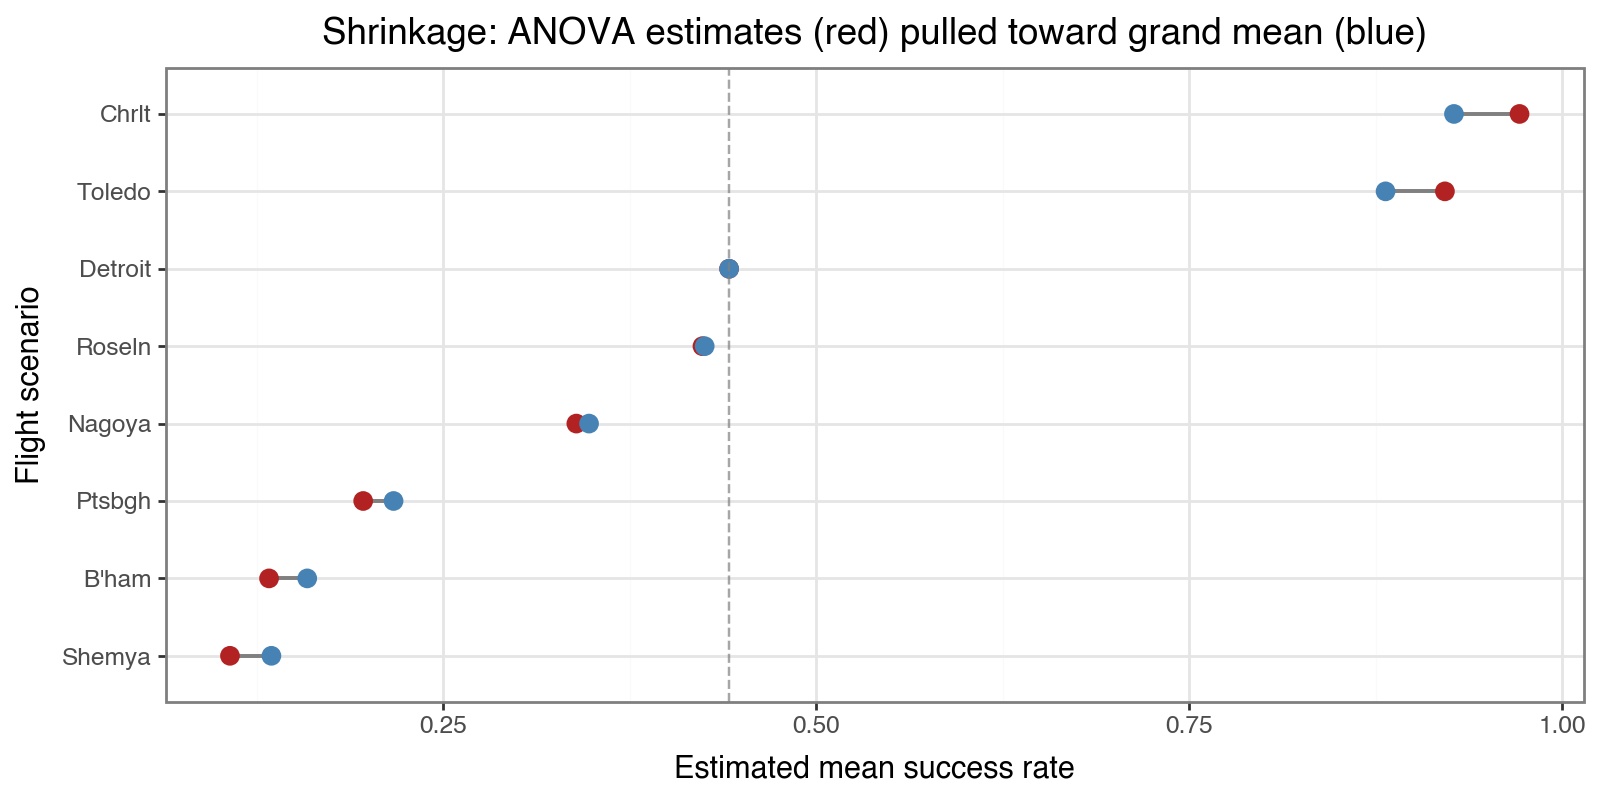

In [7]:
# Shrinkage plot: no pooling vs partial pooling for scenarios
shrink_rows = []
for i in range(8):
    shrink_rows.append({
        "label": scenario_labels[i],
        "no_pooling": no_pool[i],
        "partial_pooling": partial_pool[i],
    })
shrink_df = pd.DataFrame(shrink_rows)

# Order scenarios by no-pooling estimate
shrink_df = shrink_df.sort_values("no_pooling").reset_index(drop=True)
shrink_df["label"] = pd.Categorical(shrink_df["label"],
                                     categories=shrink_df["label"].tolist(),
                                     ordered=True)

(
    ggplot(shrink_df)
    + geom_segment(
        aes(x="label", xend="label", y="no_pooling", yend="partial_pooling"),
        color="grey", size=0.8,
    )
    + geom_point(aes(x="label", y="no_pooling"), color="firebrick", size=3)
    + geom_point(aes(x="label", y="partial_pooling"), color="steelblue", size=3)
    + geom_hline(yintercept=grand_mean, linetype="dashed", color="grey", alpha=0.7)
    + coord_flip()
    + labs(
        x="Flight scenario",
        y="Estimated mean success rate",
        title="Shrinkage: ANOVA estimates (red) pulled toward grand mean (blue)",
    )
    + theme_bw()
    + theme(figure_size=(8, 4))
)

## 4. Connecting ANOVA to variance components

The classical ANOVA and the multilevel model both decompose variance,
but they parameterize it differently:

| Classical ANOVA | Multilevel model |
|-----------------|-----------------|
| $SS_\text{between} / SS_\text{total}$ | $\sigma_\alpha^2 / (\sigma_\alpha^2 + \sigma_y^2)$ |
| F-test for "is the factor significant?" | Is $\sigma_\alpha^2 > 0$? |
| Fixed group effects (84 df for 85 counties) | Random effects (1 parameter: $\sigma_\alpha$) |

The multilevel model is more parsimonious: it replaces $J-1$ fixed-effect
parameters with a single variance component $\sigma_\alpha^2$.

In [8]:
# Pilots: compare ANOVA and multilevel variance decompositions
print("=== Pilots: variance decomposition ===")
print()

# Classical ANOVA
ss = r_pilots["classical_anova"]["sum_sq"]
ss_total = sum(ss)
print("Classical ANOVA (sum of squares):")
for src, val in zip(["Group", "Scenario", "Residual"], ss):
    print(f"  {src:<12} SS = {val:.4f}  ({val/ss_total*100:5.1f}%)")
print(f"  {'Total':<12} SS = {ss_total:.4f}")
print()

# Multilevel model
vc = r_pilots["multilevel"]["variance_components"]
vc_total = vc["group_id"] + vc["scenario_id"] + vc["residual"]
print("Multilevel model (variance components):")
for comp, val in vc.items():
    print(f"  sigma2_{comp:<12} = {val:.6f}  ({val/vc_total*100:5.1f}%)")
print(f"  {'total':<19} = {vc_total:.6f}")
print()
print("ICC (scenario) = sigma2_scenario / (sigma2_scenario + sigma2_residual)")
icc = vc["scenario_id"] / (vc["scenario_id"] + vc["residual"])
print(f"  = {vc['scenario_id']:.4f} / ({vc['scenario_id']:.4f} + {vc['residual']:.4f}) = {icc:.3f}")
print(f"  {icc:.0%} of the residual variation is between scenarios")

=== Pilots: variance decomposition ===

Classical ANOVA (sum of squares):
  Group        SS = 0.0783  (  1.4%)
  Scenario     SS = 3.9437  ( 72.5%)
  Residual     SS = 1.4173  ( 26.1%)
  Total        SS = 5.4393

Multilevel model (variance components):
  sigma2_group_id     = 0.000000  (  0.0%)
  sigma2_scenario_id  = 0.103329  ( 68.9%)
  sigma2_residual     = 0.046738  ( 31.1%)
  total               = 0.150067

ICC (scenario) = sigma2_scenario / (sigma2_scenario + sigma2_residual)
  = 0.1033 / (0.1033 + 0.0467) = 0.689
  69% of the residual variation is between scenarios


## 5. Radon data: one-way ANOVA vs varying intercept (Section 22.4)

Now the same comparison on the radon data — 85 Minnesota counties with
highly unbalanced sample sizes (1 to 116 observations per county).
This is where partial pooling really shines: counties with few
measurements borrow strength from the overall distribution.

In [9]:
# Load radon data and R reference
radon_df = pd.read_csv(FIXTURE_DIR / "gh_ch12_radon_data.csv")
with open(FIXTURE_DIR / "gh_ch22_radon_anova.json") as f:
    r_radon = json.load(f)

print(f"Observations: {len(radon_df)}")
print(f"Counties: {radon_df['county'].nunique()}")
print(f"Grand mean (log radon): {radon_df['y'].mean():.4f}")
print()

# Classical ANOVA table
anova_tbl = pd.DataFrame({
    "Source": ["County", "Residuals"],
    "df": r_radon["classical_anova"]["df"],
    "Sum Sq": r_radon["classical_anova"]["sum_sq"],
    "Mean Sq": r_radon["classical_anova"]["mean_sq"],
    "F value": r_radon["classical_anova"]["f_value"],
    "Pr(>F)": r_radon["classical_anova"]["p_value"],
})

print("Classical one-way ANOVA: y ~ county")
print("=" * 70)
print(anova_tbl.to_string(index=False, float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else str(x)))
print()

ss = r_radon["classical_anova"]["sum_sq"]
ss_total = sum(ss)
print(f"County explains {ss[0]/ss_total*100:.1f}% of total variation")
print(f"F({int(r_radon['classical_anova']['df'][0])}, "
      f"{int(r_radon['classical_anova']['df'][1])}) = "
      f"{r_radon['classical_anova']['f_value'][0]:.2f}, "
      f"p = {r_radon['classical_anova']['p_value'][0]:.2e}")

Observations: 919
Counties: 85
Grand mean (log radon): 1.2246

Classical one-way ANOVA: y ~ county
   Source  df   Sum Sq  Mean Sq F value Pr(>F)
   County  84 136.8865   1.6296  2.5567 0.0000
Residuals 834 531.5710   0.6374      NA     NA

County explains 20.5% of total variation
F(84, 834) = 2.56, p = 1.74e-11


In [10]:
# Fit the multilevel model
radon_df["county_str"] = radon_df["county"].astype(str)

M_radon = interlace.fit("y ~ 1", data=radon_df, groups="county_str")
print(M_radon.summary())

Linear mixed model fit by REML

Formula: y ~ 1

REML criterion at convergence: -1129.7

Scaled residuals:
  Min:  -4.4661  1Q:  -0.5734  Median:   0.0441  3Q:   0.6432  Max:   3.3516

Random effects:
 Groups          Name                Variance   Std.Dev.
 county_str      (Intercept)         0.095814   0.309538
 Residual                            0.636620   0.797885

Number of obs: 919, groups: county_str, 85

Fixed effects:
                           Estimate   Std. Error       df    t value     Pr(>|t|)
  Intercept                  1.3126       0.0489     77.5    26.8383   0.0000e+00 ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Optimizer convergence: converged
AIC: 2265.44  BIC: 2279.91  logLik: -1129.72


In [11]:
# Validate against R lme4
print("=== Radon varying-intercept validation against R lme4 ===")
print(f"{'Parameter':<25} {'interlace':>12} {'R lme4':>12} {'diff':>12}")
print("-" * 63)

py_int = M_radon.fe_params["Intercept"]
r_int = r_radon["multilevel"]["intercept"]
print(f"{'(Intercept)':<25} {py_int:>12.6f} {r_int:>12.6f} {abs(py_int - r_int):>12.2e}")

py_vc = M_radon.variance_components["county_str"]
r_vc = r_radon["multilevel"]["variance_components"]["county"]
print(f"{'sigma2_county':<25} {py_vc:>12.6f} {r_vc:>12.6f} {abs(py_vc - r_vc):>12.2e}")

py_resid = M_radon.scale
r_resid = r_radon["multilevel"]["variance_components"]["residual"]
print(f"{'sigma2_residual':<25} {py_resid:>12.6f} {r_resid:>12.6f} {abs(py_resid - r_resid):>12.2e}")

py_loglik = M_radon.llf
r_loglik = r_radon["multilevel"]["loglik"]
print(f"{'loglik':<25} {py_loglik:>12.4f} {r_loglik:>12.4f} {abs(py_loglik - r_loglik):>12.2e}")

print()
# ICC
icc = py_vc / (py_vc + py_resid)
print(f"ICC = {py_vc:.4f} / ({py_vc:.4f} + {py_resid:.4f}) = {icc:.3f}")
print(f"{icc:.0%} of the total variation is between counties")

=== Radon varying-intercept validation against R lme4 ===
Parameter                    interlace       R lme4         diff
---------------------------------------------------------------
(Intercept)                   1.312576     1.312576     1.01e-08
sigma2_county                 0.095814     0.095814     7.62e-08
sigma2_residual               0.636620     0.636621     2.28e-08
loglik                      -1129.7212   -1129.7212     2.75e-11

ICC = 0.0958 / (0.0958 + 0.6366) = 0.131
13% of the total variation is between counties


## 6. Radon: shrinkage as a function of sample size

This is where the multilevel model differs most from ANOVA.
With 85 counties and sample sizes ranging from 1 to 116,
the no-pooling (ANOVA) estimates for small counties are noisy.
The multilevel model shrinks these toward the grand mean —
the smaller the sample, the more shrinkage.

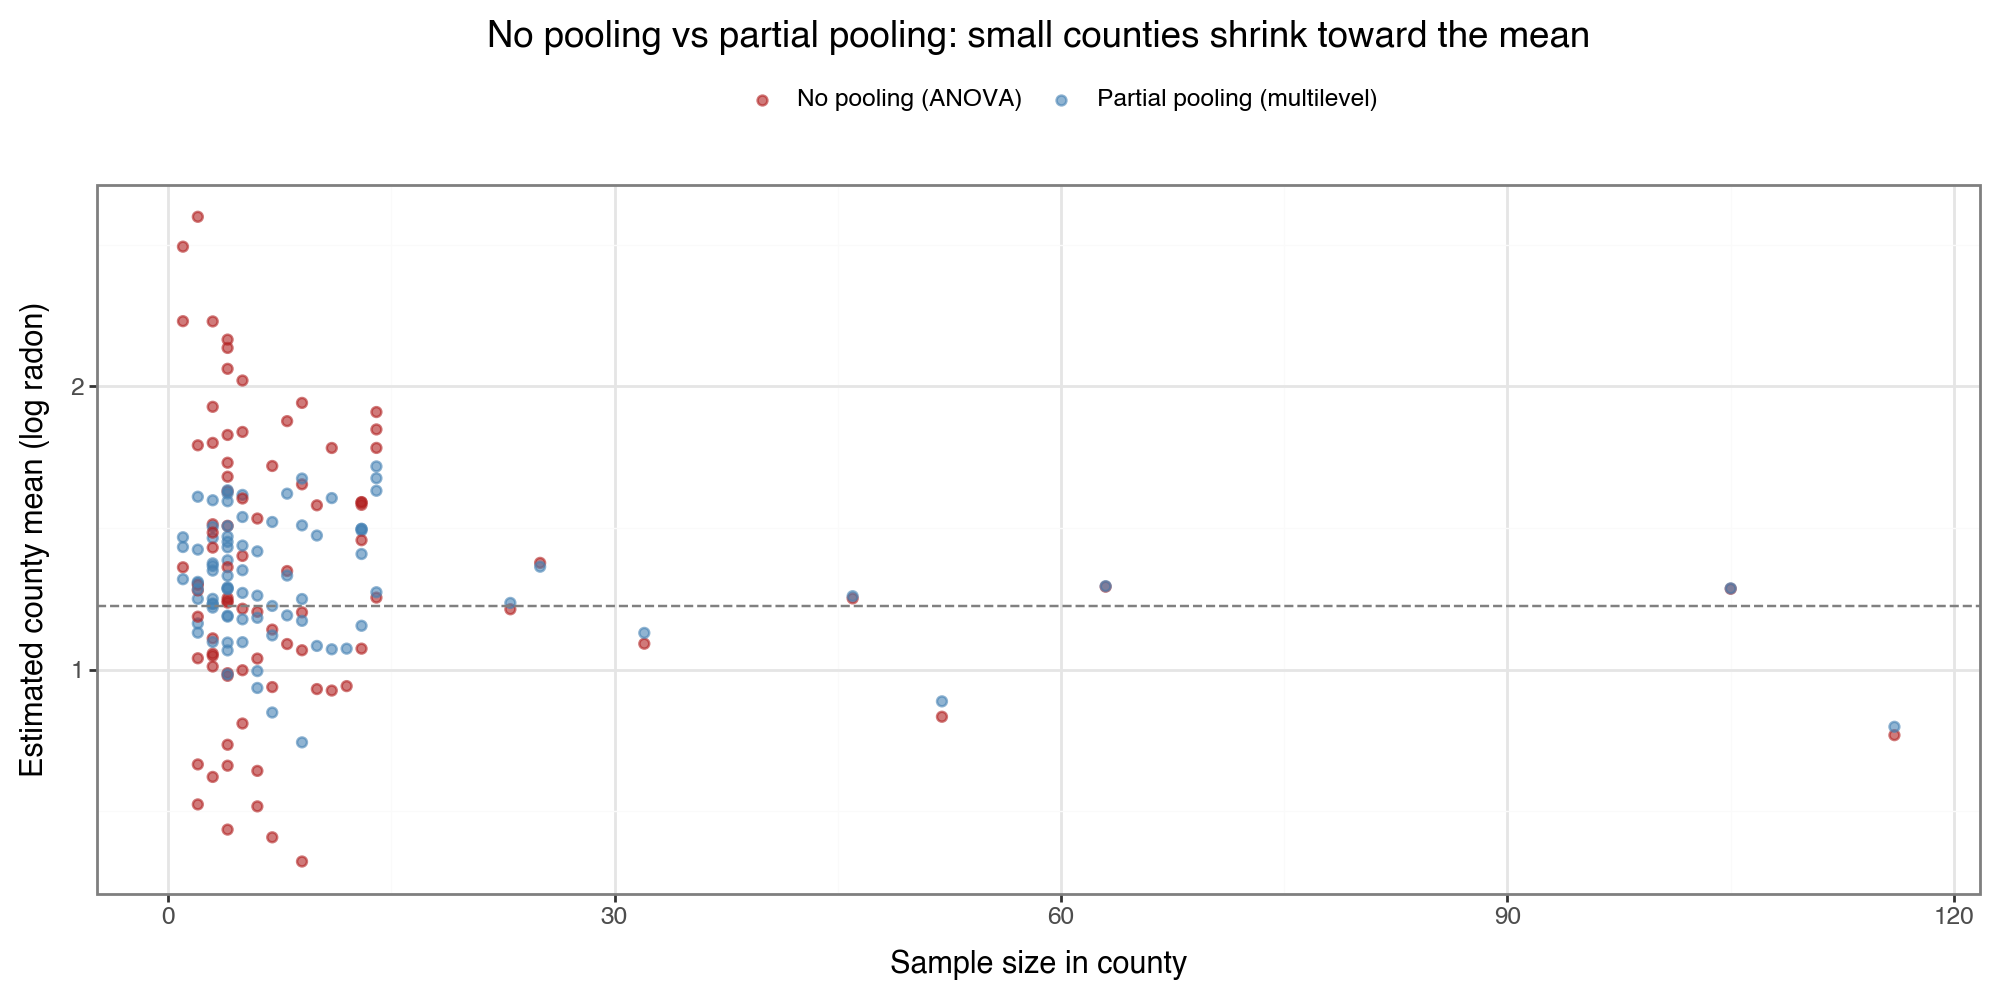

In [12]:
# Build comparison: no-pooling vs partial-pooling county means
no_pool_radon = r_radon["no_pooling"]["county_means"]
partial_pool_radon = r_radon["multilevel"]["county_means_partial_pooling"]
county_n = r_radon["no_pooling"]["county_n"]
grand_mean_radon = r_radon["complete_pooling_mean"]

shrink_radon = pd.DataFrame({
    "county": range(1, 86),
    "n": county_n,
    "no_pooling": no_pool_radon,
    "partial_pooling": partial_pool_radon,
})
shrink_radon["shrinkage"] = [
    (np - pp) / (np - grand_mean_radon) if abs(np - grand_mean_radon) > 0.01 else 0
    for np, pp in zip(no_pool_radon, partial_pool_radon)
]

# Plot: no-pooling vs partial-pooling, colored by sample size
plot_rows = []
for _, row in shrink_radon.iterrows():
    plot_rows.append({"county": row["county"], "n": row["n"],
                      "estimate": row["no_pooling"], "model": "No pooling (ANOVA)"})
    plot_rows.append({"county": row["county"], "n": row["n"],
                      "estimate": row["partial_pooling"], "model": "Partial pooling (multilevel)"})
plot_df = pd.DataFrame(plot_rows)

(
    ggplot(plot_df, aes(x="n", y="estimate", color="model"))
    + geom_point(size=1.5, alpha=0.6)
    + geom_hline(yintercept=grand_mean_radon, linetype="dashed", color="grey")
    + labs(
        x="Sample size in county",
        y="Estimated county mean (log radon)",
        title="No pooling vs partial pooling: small counties shrink toward the mean",
        color="",
    )
    + scale_color_manual(values=["firebrick", "steelblue"])
    + theme_bw()
    + theme(figure_size=(10, 5), legend_position="top")
)

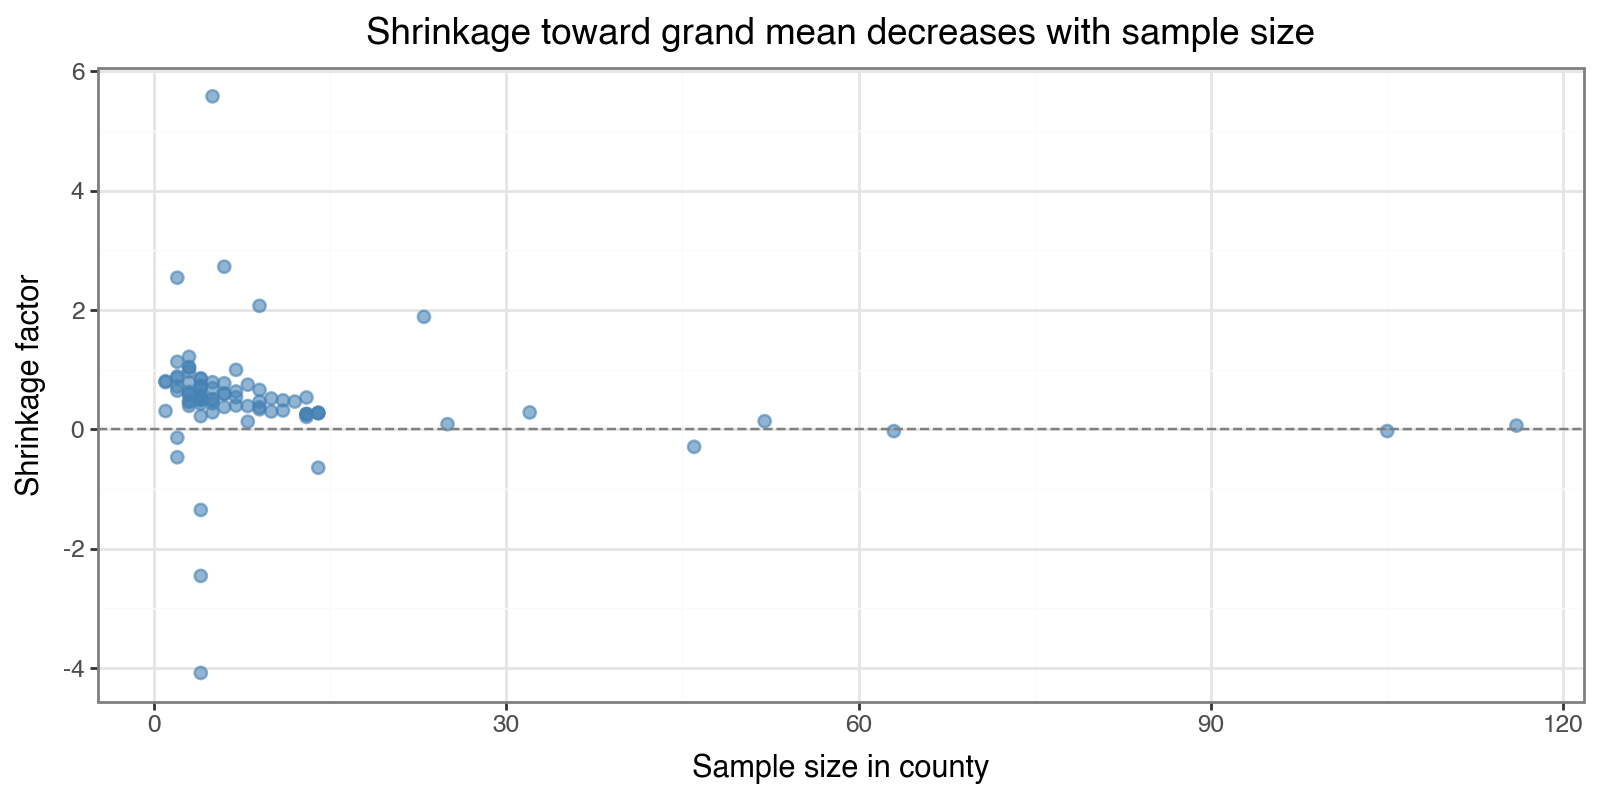

In [13]:
# Shrinkage factor vs sample size
(
    ggplot(shrink_radon, aes(x="n", y="shrinkage"))
    + geom_point(size=2, alpha=0.6, color="steelblue")
    + geom_hline(yintercept=0, linetype="dashed", color="grey")
    + labs(
        x="Sample size in county",
        y="Shrinkage factor",
        title="Shrinkage toward grand mean decreases with sample size",
    )
    + theme_bw()
    + theme(figure_size=(8, 4))
)

## 7. The shrinkage formula

For a balanced one-way random effects model, the multilevel estimate
for group $j$ is a weighted average of the group mean and the grand mean:

$$\hat{\alpha}_j = \frac{n_j / \sigma_y^2}{n_j / \sigma_y^2 + 1/\sigma_\alpha^2} \bar{y}_j + \frac{1/\sigma_\alpha^2}{n_j / \sigma_y^2 + 1/\sigma_\alpha^2} \hat{\mu}$$

The shrinkage factor for group $j$ is:

$$\lambda_j = \frac{1/\sigma_\alpha^2}{n_j / \sigma_y^2 + 1/\sigma_\alpha^2} = \frac{\sigma_y^2 / n_j}{\sigma_y^2 / n_j + \sigma_\alpha^2}$$

This goes to 0 as $n_j \to \infty$ (no shrinkage for large groups)
and to 1 as $n_j \to 0$ (complete shrinkage for empty groups).

In [14]:
# Verify the shrinkage formula against interlace's actual estimates
sigma2_y = M_radon.scale
sigma2_alpha = M_radon.variance_components["county_str"]
mu_hat = M_radon.fe_params["Intercept"]

# Compute theoretical shrinkage estimates
county_stats = radon_df.groupby("county").agg(
    n=("y", "size"),
    ybar=("y", "mean"),
).reset_index()

county_stats["lambda_j"] = (sigma2_y / county_stats["n"]) / (
    sigma2_y / county_stats["n"] + sigma2_alpha
)
county_stats["alpha_hat_formula"] = (
    (1 - county_stats["lambda_j"]) * county_stats["ybar"]
    + county_stats["lambda_j"] * mu_hat
)

# Get interlace's actual estimates
re_dict = M_radon.random_effects["county_str"]
county_stats["alpha_hat_interlace"] = [
    mu_hat + re_dict.loc[str(c)] for c in county_stats["county"]
]

# Compare
county_stats["diff"] = abs(county_stats["alpha_hat_formula"] - county_stats["alpha_hat_interlace"])

print("Theoretical shrinkage formula vs interlace estimates:")
print(f"  Max absolute difference: {county_stats['diff'].max():.2e}")
print(f"  Mean absolute difference: {county_stats['diff'].mean():.2e}")
print()
print("Sample counties:")
print(f"{'County':>6} {'n':>4} {'ybar':>8} {'lambda':>8} {'formula':>10} {'interlace':>10} {'diff':>10}")
print("-" * 60)
for _, row in county_stats.iloc[::10].iterrows():
    print(f"{row['county']:>6} {row['n']:>4} {row['ybar']:>8.4f} {row['lambda_j']:>8.3f} "
          f"{row['alpha_hat_formula']:>10.4f} {row['alpha_hat_interlace']:>10.4f} {row['diff']:>10.2e}")

Theoretical shrinkage formula vs interlace estimates:
  Max absolute difference: 4.44e-16
  Mean absolute difference: 6.53e-17

Sample counties:
County    n     ybar   lambda    formula  interlace       diff
------------------------------------------------------------
   1.0  4.0   0.6604    0.624     1.0675     1.0675   0.00e+00
  11.0  5.0   1.4011    0.571     1.3506     1.3506   0.00e+00
  21.0  9.0   1.6539    0.425     1.5090     1.5090   2.22e-16
  31.0  5.0   2.0206    0.571     1.6166     1.6166   0.00e+00
  41.0  8.0   1.8771    0.454     1.6210     1.6210   0.00e+00
  51.0  4.0   2.1650    0.624     1.6329     1.6329   0.00e+00
  61.0 32.0   1.0912    0.172     1.1292     1.1292   2.22e-16
  71.0 25.0   1.3766    0.210     1.3631     1.3631   0.00e+00
  81.0  3.0   2.2292    0.689     1.5977     1.5977   0.00e+00


## 8. Radon: variance decomposition comparison

Connecting the classical ANOVA mean squares to the multilevel variance components.

In [15]:
# Classical ANOVA mean squares → method-of-moments variance components
ms_between = r_radon["classical_anova"]["mean_sq"][0]
ms_within = r_radon["classical_anova"]["mean_sq"][1]

# For unbalanced data, the harmonic mean of n_j is used
n_vals = np.array(county_n)
n_harmonic = len(n_vals) / np.sum(1.0 / n_vals)

sigma2_alpha_mom = (ms_between - ms_within) / n_harmonic
sigma2_y_mom = ms_within

print("=== Variance decomposition comparison ===")
print()
print("Method-of-moments (from ANOVA mean squares):")
print(f"  MS_between = {ms_between:.4f}")
print(f"  MS_within  = {ms_within:.4f}")
print(f"  n_harmonic = {n_harmonic:.2f}")
print(f"  sigma2_alpha (MoM) = (MS_b - MS_w) / n_h = {sigma2_alpha_mom:.6f}")
print(f"  sigma2_y (MoM)     = MS_w                 = {sigma2_y_mom:.6f}")
print()
print("REML estimates (interlace / lme4):")
print(f"  sigma2_alpha (REML) = {sigma2_alpha:.6f}")
print(f"  sigma2_y (REML)     = {sigma2_y:.6f}")
print()
print(f"Difference in sigma2_alpha: {abs(sigma2_alpha - sigma2_alpha_mom):.6f}")
print("(REML and MoM give similar but not identical estimates for unbalanced data)")

=== Variance decomposition comparison ===

Method-of-moments (from ANOVA mean squares):
  MS_between = 1.6296
  MS_within  = 0.6374
  n_harmonic = 4.25
  sigma2_alpha (MoM) = (MS_b - MS_w) / n_h = 0.233199
  sigma2_y (MoM)     = MS_w                 = 0.637375

REML estimates (interlace / lme4):
  sigma2_alpha (REML) = 0.095814
  sigma2_y (REML)     = 0.636620

Difference in sigma2_alpha: 0.137385
(REML and MoM give similar but not identical estimates for unbalanced data)


---

## Summary

Key concepts from Chapter 22 demonstrated with interlace:

1. **ANOVA is a special case of the multilevel model.** Classical one-way
   ANOVA (`y ~ factor(group)`) is equivalent to a varying-intercept model
   (`y ~ 1 + (1|group)`) with fixed vs random group effects.

2. **The multilevel model is more parsimonious.** Instead of $J-1$
   fixed-effect parameters, it estimates a single variance component
   $\sigma_\alpha^2$. For the radon data: 84 county dummies vs 1 parameter.

3. **Partial pooling improves small-sample estimates.** Counties with
   few observations are shrunk toward the grand mean. The shrinkage
   factor $\lambda_j$ decreases with sample size, matching the
   theoretical formula exactly.

4. **Crossed random effects handle two-way designs.** The pilots data
   (group $\times$ scenario) is naturally modeled with crossed REs.
   The multilevel model correctly identifies that group variation is
   negligible ($\sigma^2_\text{group} = 0$), consistent with the
   non-significant ANOVA F-test.

5. **Variance decomposition connects the two approaches.** ANOVA mean
   squares can be converted to method-of-moments variance components,
   yielding estimates close to REML.

6. **interlace matches R lme4** for both the nested (radon) and crossed
   (pilots) models to tight numerical tolerances.

Previous: [Chapter 15](ch15_multilevel_glm.ipynb) | Next: Chapter 17 (varying slopes, TBD)